Uniform plot saved.


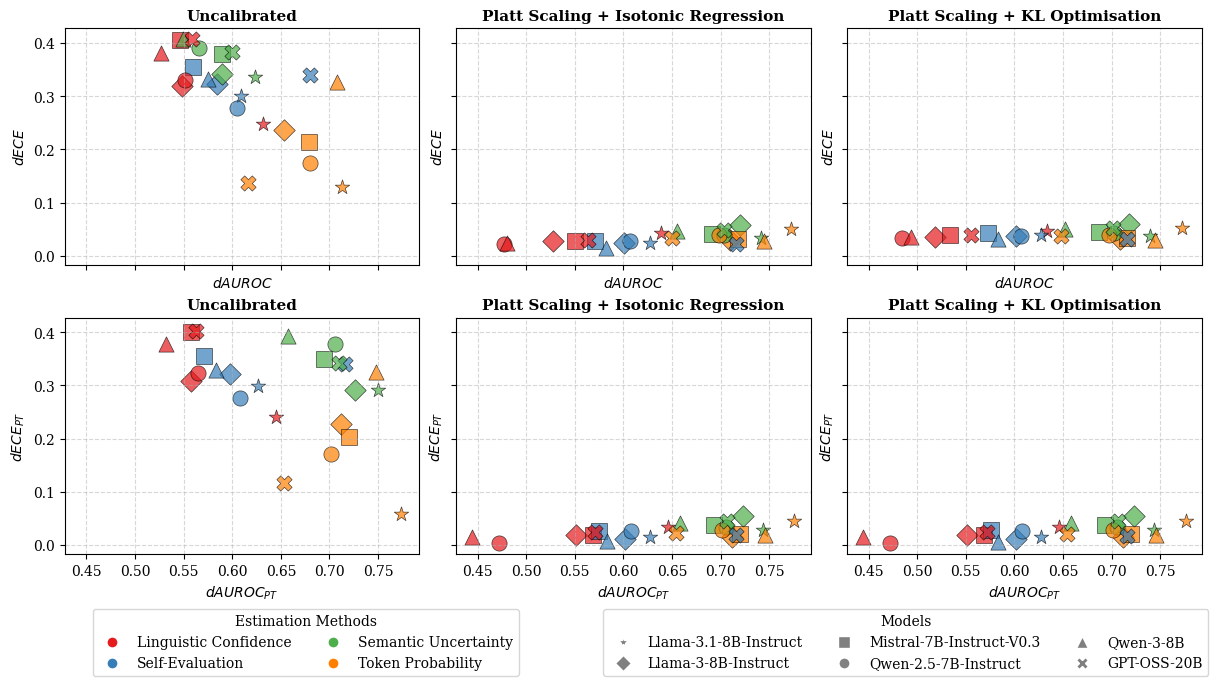

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

dataset = "squadv2"

# Use serif fonts at size 10 for all plot text
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
})
df = pd.read_csv(f"calibration_table_{dataset}.csv")

# Map definitions
model_markers = {
    'LLAMA-3.1-8B-INSTRUCT': '*',
    'META-LLAMA-3-8B-INSTRUCT': 'D',
    'MISTRAL-7B-INSTRUCT-V0.3': 's',
    'QWEN2.5-7B-INSTRUCT': 'o',
    'QWEN3-8B': '^',
    'GPT-OSS-20B': 'X'
}
model_names = {
    'LLAMA-3.1-8B-INSTRUCT': 'Llama-3.1-8B-Instruct',
    'META-LLAMA-3-8B-INSTRUCT': 'Llama-3-8B-Instruct',
    'MISTRAL-7B-INSTRUCT-V0.3': 'Mistral-7B-Instruct-V0.3',
    'QWEN2.5-7B-INSTRUCT': 'Qwen-2.5-7B-Instruct',
    'QWEN3-8B': 'Qwen-3-8B',
    'GPT-OSS-20B': 'GPT-OSS-20B'
}
method_colors = {
    'Linguistic Confidence': '#E41A1C', 
    'Self-Evaluation': '#377EB8',
    'Semantic Uncertainty': '#4DAF4A',
    'Token Probability': '#FF7F00'
}

# Determine global scales for uniform axes
all_auroc = df[['raw_dAUROC', 'raw_dAUROC_pt', 'dAUROC_reg', 'dAUROC_pt_reg', 'dAUROC_kl', 'dAUROC_pt_kl']].values.flatten()
all_ece = df[['raw_dECE', 'raw_dECE_pt', 'dECE_reg', 'dECE_pt_reg', 'dECE_kl', 'dECE_pt_kl']].values.flatten()

x_lims = (all_auroc.min() * 0.95, all_auroc.max() * 1.05)
y_lims = (all_ece.min() * 0.95, all_ece.max() * 1.05)

# Plotting configuration
metrics = [
    [('raw_dAUROC', 'raw_dECE', 'Uncalibrated'), ('dAUROC_reg', 'dECE_reg', 'Platt Scaling + Isotonic Regression'), ('dAUROC_kl', 'dECE_kl', 'Platt Scaling + KL Optimisation')],
    [('raw_dAUROC_pt', 'raw_dECE_pt', 'Uncalibrated'), ('dAUROC_pt_reg', 'dECE_pt_reg', 'Platt Scaling + Isotonic Regression'), ('dAUROC_pt_kl', 'dECE_pt_kl', 'Platt Scaling + KL Optimisation')]
]

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True, constrained_layout=True)

for r in range(2):
    for c in range(3):
        ax = axes[r, c]
        x_col, y_col, title = metrics[r][c]
        
        for model, marker in model_markers.items():
            for method, color in method_colors.items():
                point = df[(df['Model'] == model) & (df['Estimation Method'] == method)]
                if not point.empty:
                    ax.scatter(point[x_col], point[y_col], color=color, marker=marker, s=120, edgecolors='k', linewidths=0.5, alpha=0.7)

                if r == 0:
                    ax.set_xlabel(r'$dAUROC$')
                    ax.set_ylabel(r'$dECE$')
                else:
                    ax.set_xlabel(rf'$dAUROC_{{PT}}$')
                    ax.set_ylabel(r'$dECE_{PT}$')
        
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.5)
        
        

    # Shared Legends
method_leg = [Line2D([0], [0], marker='o', color='w', markerfacecolor=c, label=m, markersize=8) for m, c in method_colors.items()]
model_leg = [Line2D([0], [0], marker=s, color='w', markerfacecolor='gray', label=model_names[m], markersize=8) for m, s in model_markers.items()]

fig.legend(handles=method_leg, title="Estimation Methods", loc='lower center', bbox_to_anchor=(0.25, -0.13), ncol=2, frameon=True)
fig.legend(handles=model_leg, title="Models", loc='lower center', bbox_to_anchor=(0.75, -0.13), ncol=3, frameon=True)

plt.savefig(f'post_hoc_calibration_scattered_plot_{dataset}.pdf', dpi=300, bbox_inches='tight')
print("Uniform plot saved.")